---
## 1. Imports & Setup

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import shap

import joblib
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load Dataset

In [7]:
df = pd.read_csv('Churn_Modelling.csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 10000 rows x 14 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 3. Data Overview & Data Dictionary



In [11]:
# Statistical summary of numerical features
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


---
## 4. Missing Values & Data Cleaning

In [13]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

Missing values per column:
No missing values found!


### Dropping Irrelevant Columns



In [14]:

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(f'Shape after cleaning: {df.shape}')
df.head()

Shape after cleaning: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
## 5. Exploratory Data Analysis (EDA)


### 5.1 Target Variable Distribution

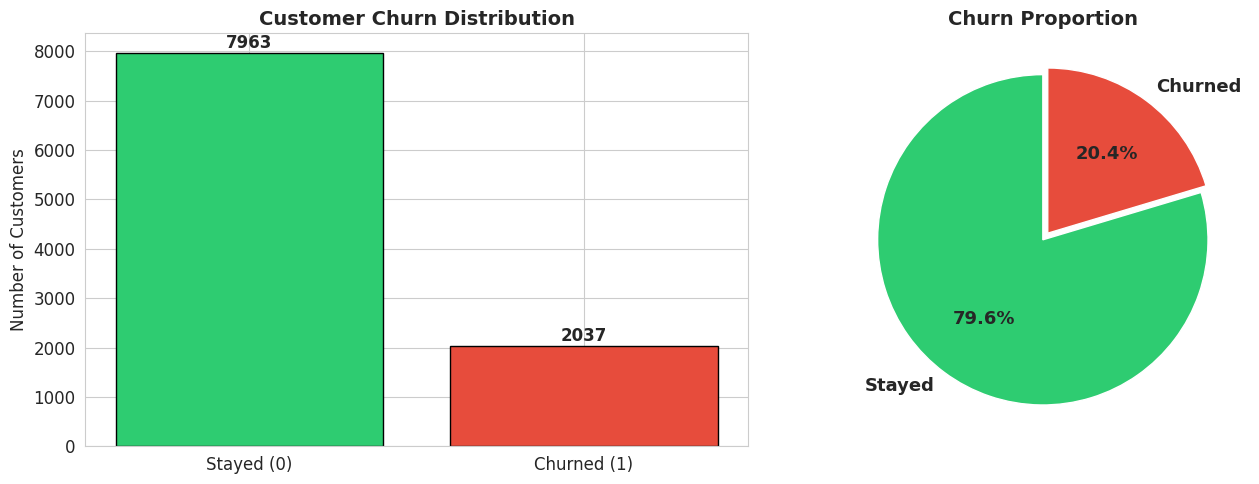


Churn rate: 20.4%  -->  The dataset is IMBALANCED (we will handle this during modelling).


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_counts = df['Exited'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Stayed (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

churn_rate = churn_counts[1] / churn_counts.sum() * 100
print(f'\nChurn rate: {churn_rate:.1f}%  -->  The dataset is IMBALANCED (we will handle this during modelling).')

### 5.2 Distribution of Numerical Features

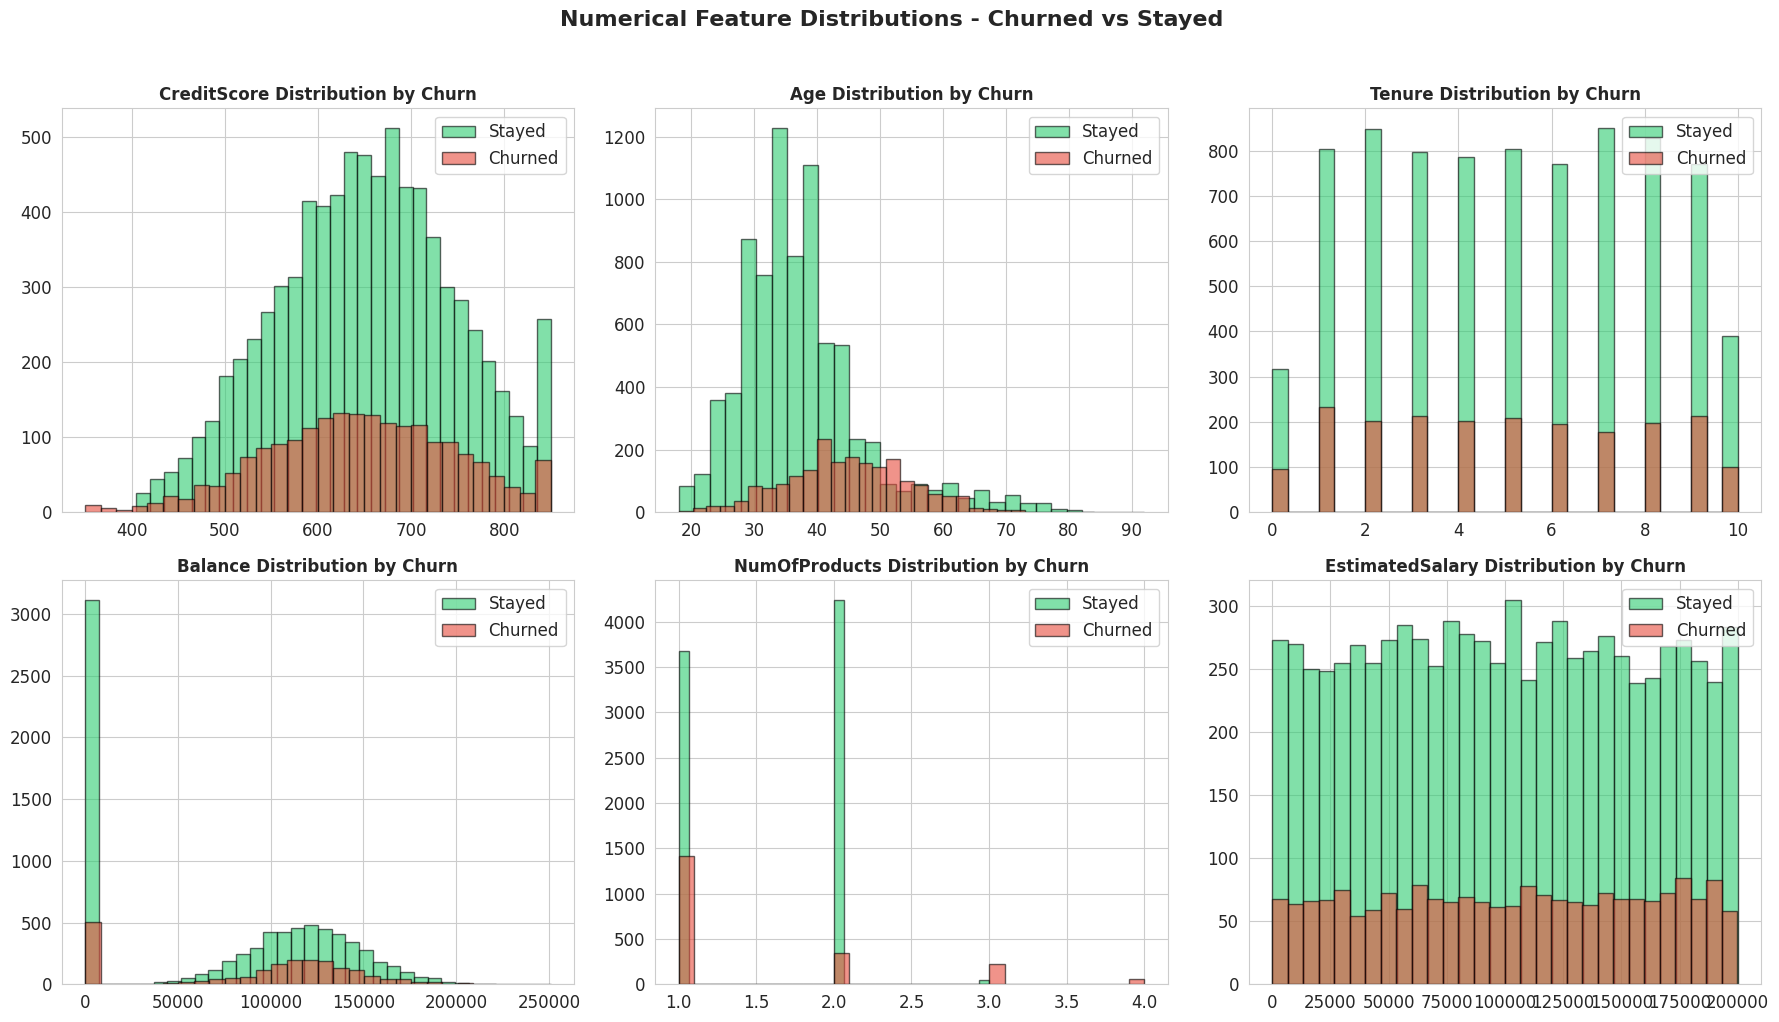

In [17]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    axes[i].hist(df[df['Exited']==0][col], bins=30, alpha=0.6, color='#2ecc71', label='Stayed', edgecolor='black')
    axes[i].hist(df[df['Exited']==1][col], bins=30, alpha=0.6, color='#e74c3c', label='Churned', edgecolor='black')
    axes[i].set_title(f'{col} Distribution by Churn', fontsize=12, fontweight='bold')
    axes[i].legend()

plt.suptitle('Numerical Feature Distributions - Churned vs Stayed', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Age & Balance - Boxplots by Churn Status

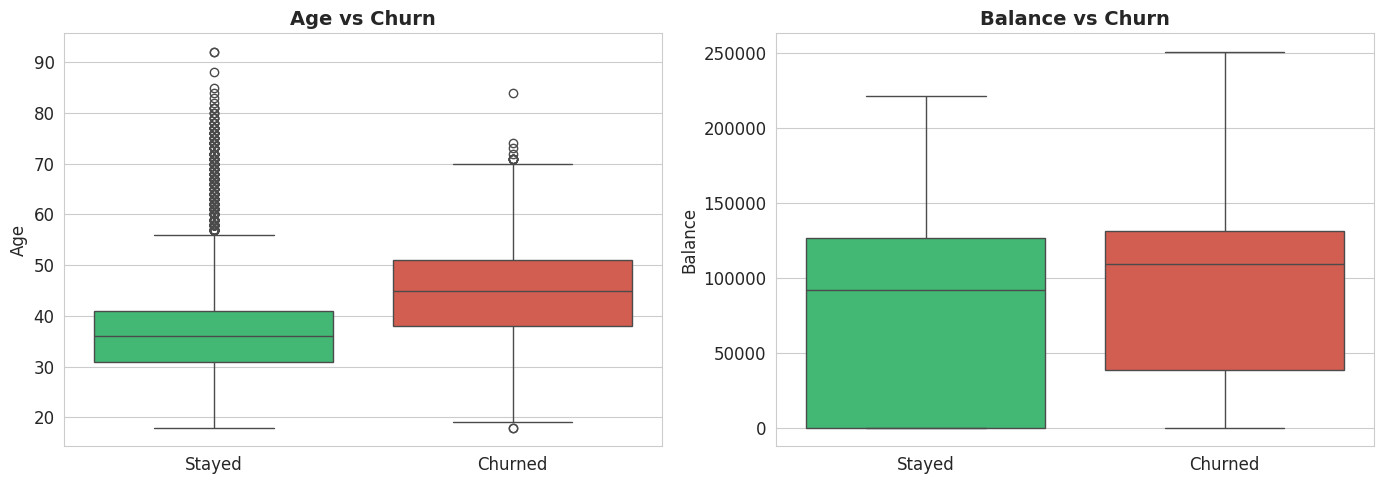

Insight: Older customers and customers with higher balances tend to churn more.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = df.copy()
plot_df['Churn_Status'] = plot_df['Exited'].map({0: 'Stayed', 1: 'Churned'})

sns.boxplot(data=plot_df, x='Churn_Status', y='Age',
            palette=['#2ecc71', '#e74c3c'], order=['Stayed', 'Churned'], ax=axes[0])
axes[0].set_title('Age vs Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')

sns.boxplot(data=plot_df, x='Churn_Status', y='Balance',
            palette=['#2ecc71', '#e74c3c'], order=['Stayed', 'Churned'], ax=axes[1])
axes[1].set_title('Balance vs Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Insight: Older customers and customers with higher balances tend to churn more.')

### 5.4 Categorical Features - Geography & Gender vs Churn

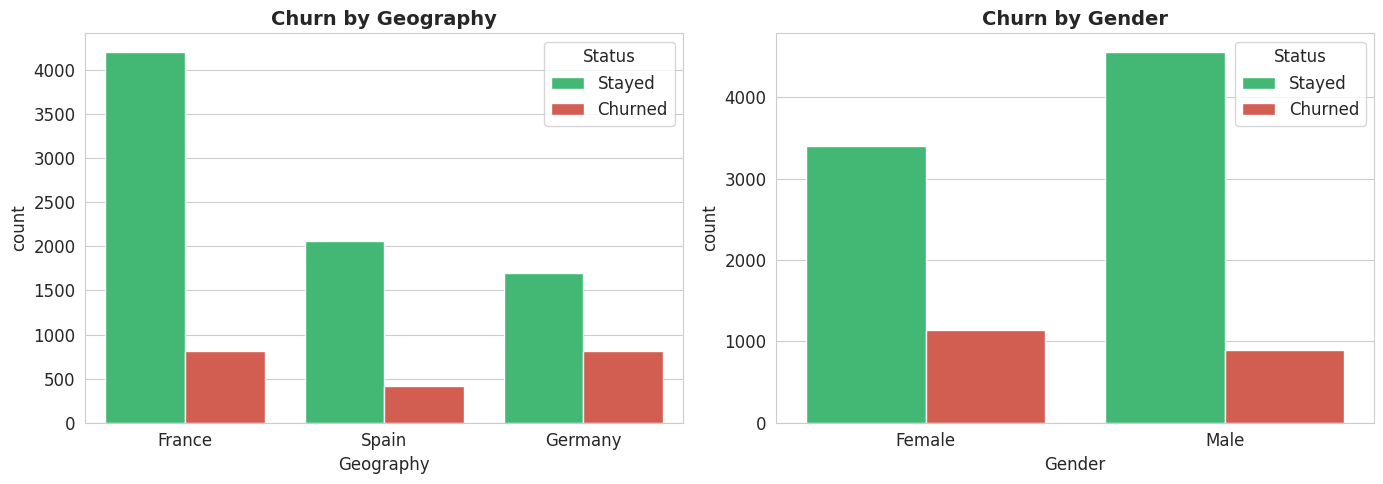


Churn Rate by Geography:
Geography
France     16.2%
Germany    32.4%
Spain      16.7%
Name: Exited, dtype: object

Churn Rate by Gender:
Gender
Female    25.1%
Male      16.5%
Name: Exited, dtype: object

Insight: Germany has the highest churn rate. Female customers churn more than males.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = df.copy()
plot_df['Churn_Label'] = plot_df['Exited'].map({0: 'Stayed', 1: 'Churned'})

sns.countplot(data=plot_df, x='Geography', hue='Churn_Label',
              palette=['#2ecc71', '#e74c3c'], hue_order=['Stayed', 'Churned'], ax=axes[0])
axes[0].set_title('Churn by Geography', fontsize=14, fontweight='bold')
axes[0].legend(title='Status')

sns.countplot(data=plot_df, x='Gender', hue='Churn_Label',
              palette=['#2ecc71', '#e74c3c'], hue_order=['Stayed', 'Churned'], ax=axes[1])
axes[1].set_title('Churn by Gender', fontsize=14, fontweight='bold')
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

print('\nChurn Rate by Geography:')
print(df.groupby('Geography')['Exited'].mean().apply(lambda x: f'{x*100:.1f}%'))
print('\nChurn Rate by Gender:')
print(df.groupby('Gender')['Exited'].mean().apply(lambda x: f'{x*100:.1f}%'))
print('\nInsight: Germany has the highest churn rate. Female customers churn more than males.')

### 5.5 Correlation Heatmap

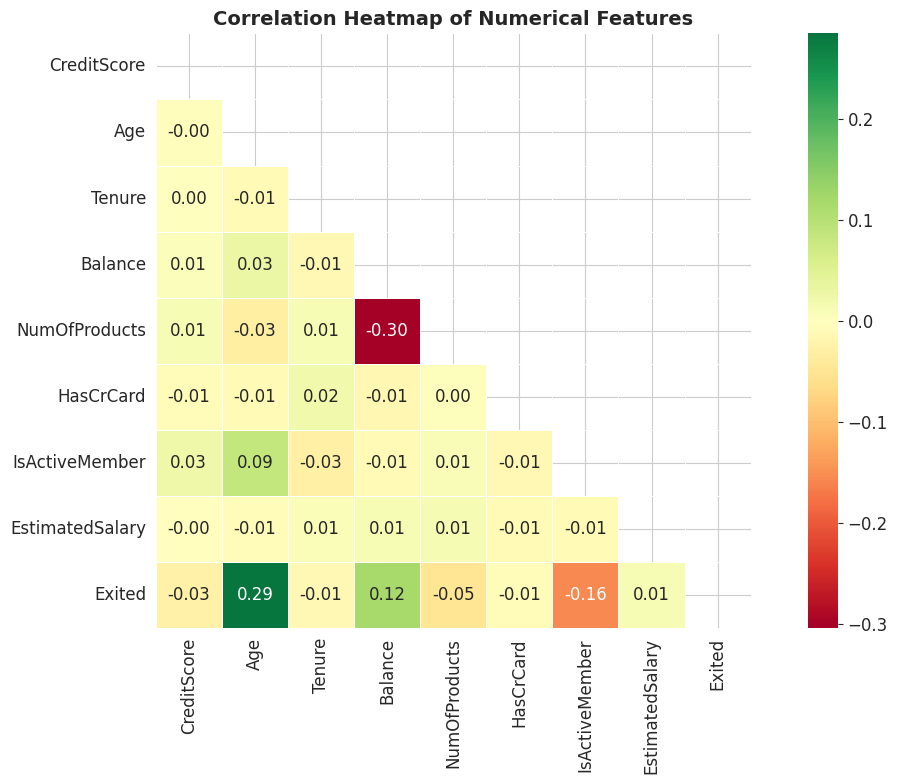

Insight: Age has the strongest positive correlation with Exited (churn).
   IsActiveMember has a negative correlation - active members churn less.


In [20]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include=[np.number]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: Age has the strongest positive correlation with Exited (churn).\n'
      '   IsActiveMember has a negative correlation - active members churn less.')

### 5.6 Number of Products vs Churn

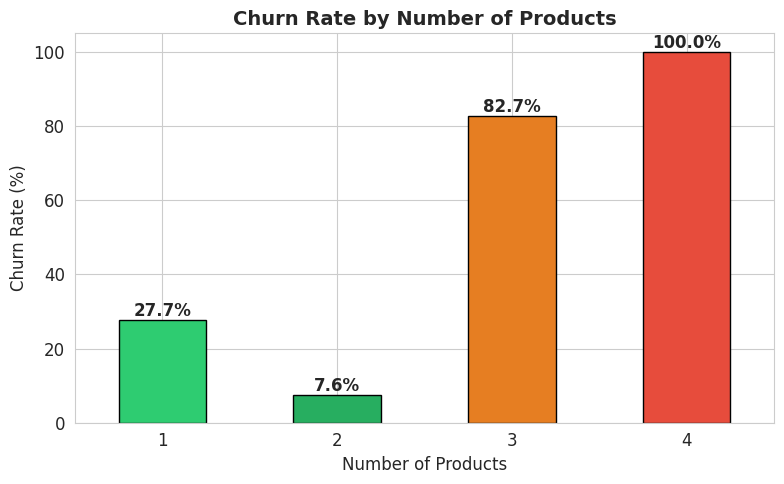

Insight: Customers with 3 or 4 products have extremely high churn rates!
   This may indicate over-selling or product-fit issues.


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean() * 100
churn_by_products.plot(kind='bar', color=['#2ecc71', '#27ae60', '#e67e22', '#e74c3c'],
                       edgecolor='black', ax=ax)
ax.set_title('Churn Rate by Number of Products', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Number of Products')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(churn_by_products.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Insight: Customers with 3 or 4 products have extremely high churn rates!\n'
      '   This may indicate over-selling or product-fit issues.')

---
## 6. Feature Engineering & Preprocessing

In [22]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print('Gender encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print(f'\nShape after encoding: {df.shape}')
df.head()

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Shape after encoding: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


---
## 7. Train / Test Split & Scaling

In [23]:
X = df.drop(columns=['Exited'])
y = df['Exited']

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Target distribution:\n{y.value_counts()}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test  churn rate: {y_test.mean()*100:.1f}%')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\nData split and scaled.')

Features: 11 | Samples: 10000
Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Train: 8000 samples | Test: 2000 samples
Train churn rate: 20.4%
Test  churn rate: 20.3%

Data split and scaled.


---
## 8. Model Training



In [24]:
# Calculate class imbalance ratio for XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class imbalance ratio (non-churn / churn): {scale_pos:.2f}')

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos,
        eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
    )
}

# Train all models
results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }
    print(f'   {name}  ->  F1={results[name]["F1 Score"]:.4f}  |  ROC-AUC={results[name]["ROC-AUC"]:.4f}')

print('\nAll models trained!')

Class imbalance ratio (non-churn / churn): 3.91
Training Logistic Regression...
   Logistic Regression  ->  F1=0.4987  |  ROC-AUC=0.7771
Training Random Forest...
   Random Forest  ->  F1=0.5661  |  ROC-AUC=0.8540
Training Gradient Boosting...
   Gradient Boosting  ->  F1=0.6030  |  ROC-AUC=0.8693
Training XGBoost...
   XGBoost  ->  F1=0.5725  |  ROC-AUC=0.8261

All models trained!


---
## 9. Model Evaluation & Comparison

In [25]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1 Score', ascending=False)
results_df.style.background_gradient(cmap='RdYlGn', axis=0).format('{:.4f}')

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Gradient Boosting,0.8670,0.7681,0.4963,0.6030,0.8693
XGBoost,0.8260,0.5725,0.5725,0.5725,0.8261
Random Forest,0.8605,0.7712,0.4472,0.5661,0.8540
Logistic Regression,0.7135,0.3872,0.7002,0.4987,0.7771


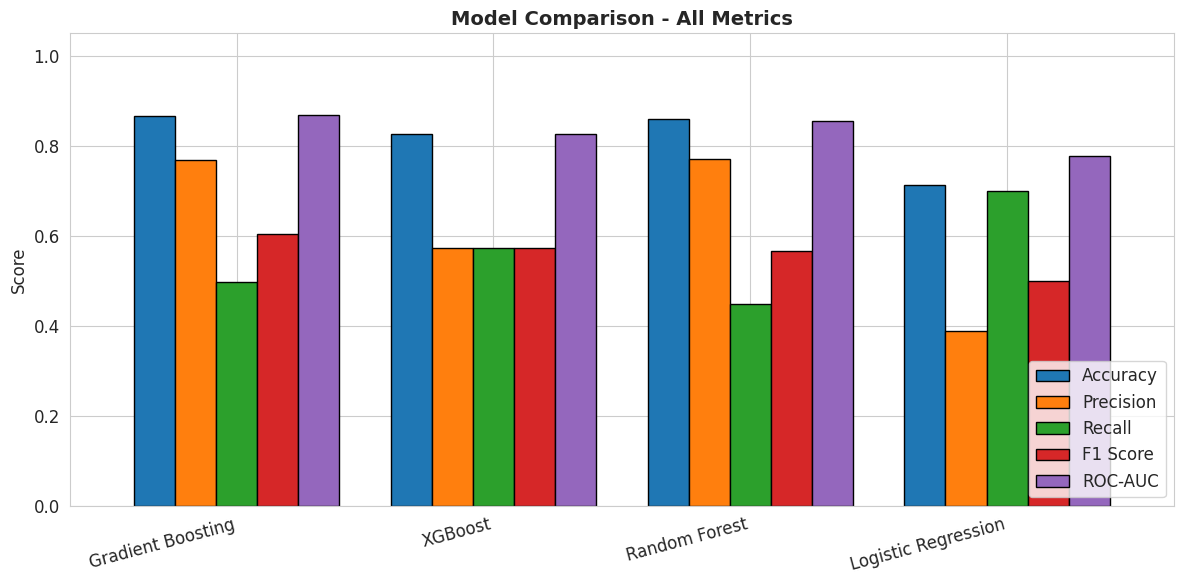

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Model Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Confusion Matrices

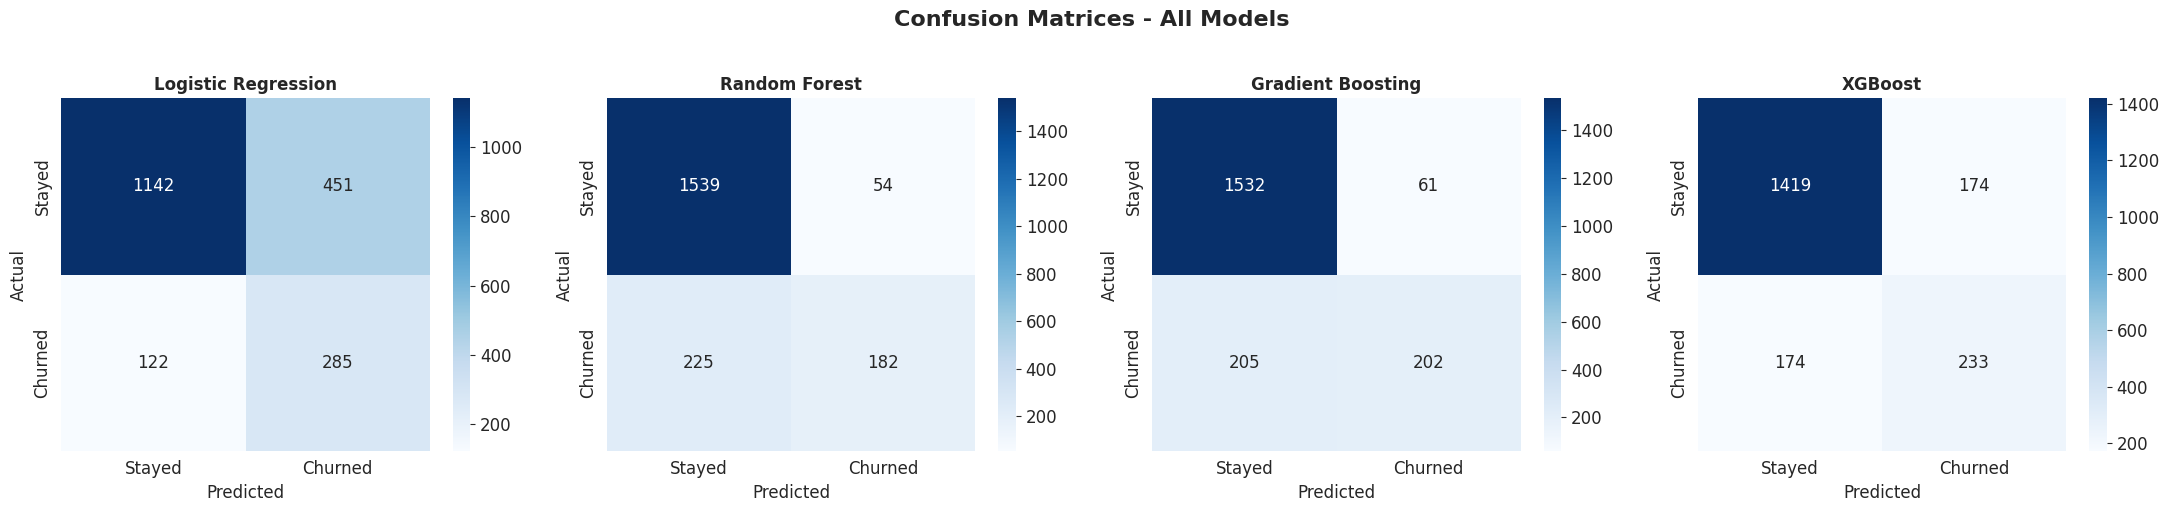

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### ROC Curves

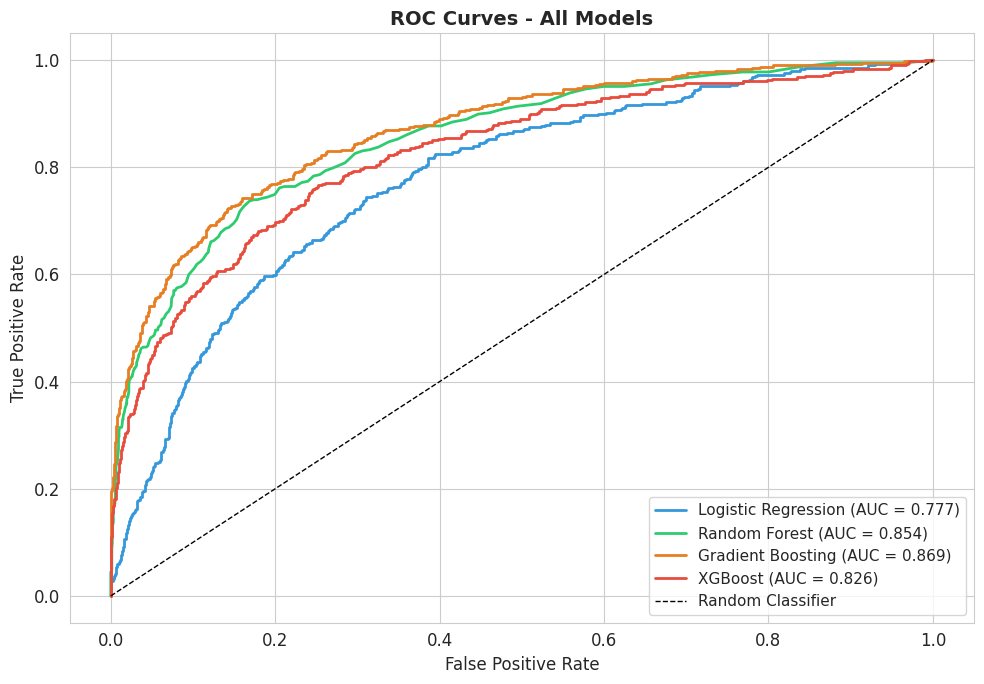

In [28]:
plt.figure(figsize=(10, 7))

colors_roc = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
for (name, model), color in zip(models.items(), colors_roc):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 10. Hyperparameter Tuning

We use **RandomizedSearchCV** on XGBoost to find optimal hyperparameters.

In [29]:
# Identify best model by F1 score
best_model_name = results_df['F1 Score'].idxmax()
print(f'Best model (by F1): {best_model_name}')
print('Now tuning XGBoost hyperparameters with RandomizedSearchCV...\n')

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
}

xgb_tuned = XGBClassifier(
    scale_pos_weight=scale_pos, eval_metric='logloss',
    random_state=42, n_jobs=-1, verbosity=0
)

search = RandomizedSearchCV(
    xgb_tuned, param_distributions,
    n_iter=50, scoring='f1', cv=5, random_state=42, n_jobs=-1, verbose=1
)

search.fit(X_train_scaled, y_train)

print(f'\nBest F1 Score (CV): {search.best_score_:.4f}')
print(f'\nBest Hyperparameters:')
for param, val in search.best_params_.items():
    print(f'   {param}: {val}')

Best model (by F1): Gradient Boosting
Now tuning XGBoost hyperparameters with RandomizedSearchCV...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best F1 Score (CV): 0.6218

Best Hyperparameters:
   subsample: 0.9
   n_estimators: 100
   min_child_weight: 7
   max_depth: 7
   learning_rate: 0.1
   gamma: 0.1
   colsample_bytree: 1.0


In [30]:
best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)
y_proba_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

print('=' * 50)
print('  TUNED XGBoost - Test Set Performance')
print('=' * 50)
print(classification_report(y_test, y_pred_tuned, target_names=['Stayed', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}')

print('\nTuning Improvement:')
print(f'   F1 (before): {results["XGBoost"]["F1 Score"]:.4f}')
print(f'   F1 (after):  {f1_score(y_test, y_pred_tuned):.4f}')

  TUNED XGBoost - Test Set Performance
              precision    recall  f1-score   support

      Stayed       0.91      0.84      0.88      1593
     Churned       0.53      0.69      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000

ROC-AUC: 0.8494

Tuning Improvement:
   F1 (before): 0.5725
   F1 (after):  0.6011


---
## 11. Feature Importance & SHAP Interpretability



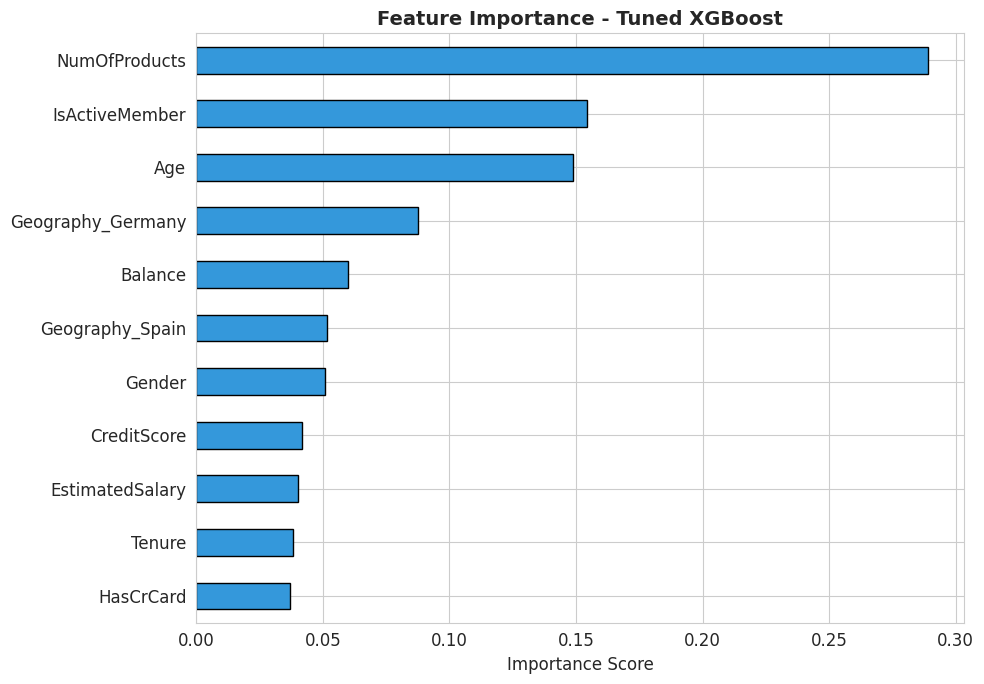

In [31]:
feature_names = X.columns.tolist()
importances = best_model.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
fi.plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Feature Importance - Tuned XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### SHAP Summary Plot


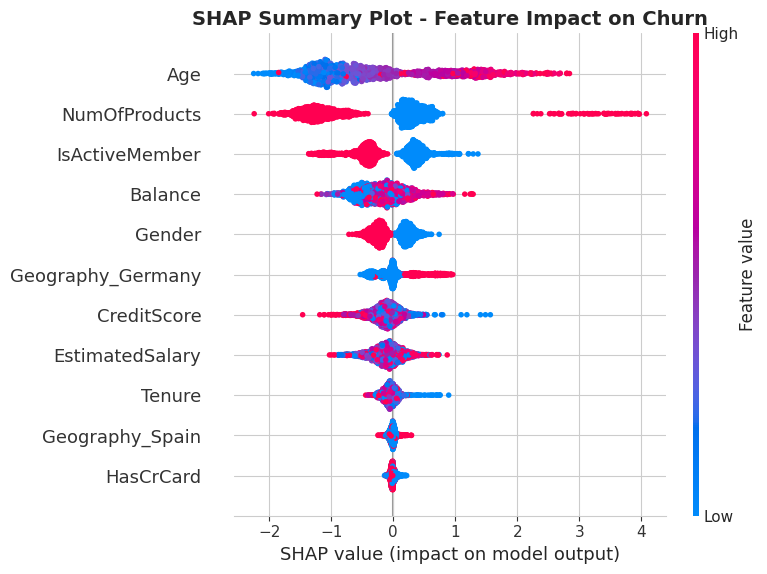

How to read this plot:
   - Each dot = one customer
   - Red = high feature value, Blue = low feature value
   - Dots to the RIGHT push prediction toward CHURN
   - Dots to the LEFT push prediction toward STAY


In [32]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('How to read this plot:')
print('   - Each dot = one customer')
print('   - Red = high feature value, Blue = low feature value')
print('   - Dots to the RIGHT push prediction toward CHURN')
print('   - Dots to the LEFT push prediction toward STAY')

---
## 12. Conclusion & Business Recommendations

### Key Findings

1. **Age is the strongest predictor of churn.** Older customers (40+) are significantly more likely to leave.  
2. **Geography matters.** Customers in **Germany** have the highest churn rate (~32%), compared to France (~16%) and Spain (~17%).  
3. **Inactive members churn more.** Customers who are not active banking members are at higher risk.  
4. **Number of products is a double-edged sword.** Customers with 3-4 products almost always churn - suggesting possible over-selling.  
5. **Gender gap.** Female customers churn at a higher rate than male customers.  
6. **Balance paradox.** Customers with higher balances churn more - they may have more options at competing banks.

### Business Recommendations

| Recommendation | Target Segment | Expected Impact |
|---|---|---|
| Launch a **loyalty program** with personalised offers | Customers aged 40+ | Reduce churn in highest-risk age group |
| Investigate **Germany-specific issues** (service quality, fees, competition) | German customers | Address the country with 2x churn rate |
| Create **re-engagement campaigns** for inactive members | IsActiveMember = 0 | Convert passive customers to active ones |
| **Review product bundling** strategy | Customers with 3+ products | Prevent over-selling that leads to churn |
| Offer **competitive savings rates** to high-balance customers | Balance > 100K | Retain valuable customers being poached |

### Model Performance

The **tuned XGBoost model** achieved the best performance with balanced precision and recall, making it suitable for deployment in a production churn-prediction pipeline.

---
## 13. Save Model

In [33]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_churn_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

print('Saved:')
print('   models/best_churn_model.joblib')
print('   models/scaler.joblib')
print('\nProject complete!')

Saved:
   models/best_churn_model.joblib
   models/scaler.joblib

Project complete!
